# Lab 11: Convolutional Neural Networks - SOLUTION
## MPS311/439 - Machine Learning
**Week 11 Lab Session**

---

This notebook contains complete solutions with detailed explanations for the CNN lab.

**Learning Objectives:**
- Build CNNs using Keras
- Train CNNs on image data
- Understand what CNN filters learn
- Experiment with architecture choices
- Apply transfer learning (MPS439)

---

## Setup: Import Libraries and Load Data

**Why:** We need to load Fashion-MNIST and prepare it for CNNs.

**What:** CNNs expect images in format (height, width, channels). For grayscale, channels=1.

**How:** We reshape from (28, 28) to (28, 28, 1) and normalize pixels to [0, 1].

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models

# Load Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class names
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# CRITICAL: Reshape to add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train.shape[1:]}")
print(f"Number of classes: {len(class_names)}")
print(f"\nData ready! Shape is now (samples, height, width, channels)")

Training samples: 60000
Test samples: 10000
Image shape: (28, 28, 1)
Number of classes: 10

Data ready! Shape is now (samples, height, width, channels)


**Explanation:**
- Original shape: (60000, 28, 28)
- After reshape: (60000, 28, 28, 1)
- The -1 means "figure out this dimension automatically"
- Channel=1 because images are grayscale (not RGB)
- Normalizing to [0,1] helps neural networks train faster and better

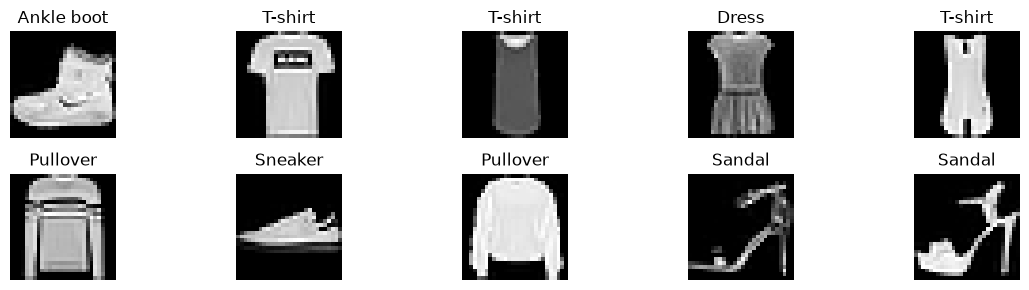

In [2]:
# Show first 10 images
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

---
## Part 1: Build Your First CNN

**Why:** CNNs are specialized for images - they preserve spatial structure and use parameter sharing.

**What:** We'll build a simple CNN with 2 convolutional blocks and 2 dense layers.

**How:** Stack Conv2D → MaxPooling2D → Conv2D → MaxPooling2D → Flatten → Dense → Dense

### Task 1.1: Create the CNN architecture

**Solution:**

In [3]:
# Create CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Model created!")
model.summary()

Model created!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**Explanation:**

**First Conv2D (32 filters):**
- Learns 32 different 3×3 patterns (edges, textures)
- Input: 28×28×1, Output: 26×26×32 (shrinks by 2 due to valid padding)
- Parameters: (3×3×1 + 1) × 32 = 320
- The +1 is the bias term for each filter

**First MaxPooling2D:**
- Reduces spatial dimensions by half
- Input: 26×26×32, Output: 13×13×32
- No learnable parameters (just takes max in each 2×2 window)

**Second Conv2D (64 filters):**
- Learns 64 more complex patterns
- Input: 13×13×32, Output: 11×11×64
- Parameters: (3×3×32 + 1) × 64 = 18,496
- Note: 32 input channels because previous layer has 32 filters!

**Second MaxPooling2D:**
- Input: 11×11×64, Output: 5×5×64
- Again no parameters

**Flatten:**
- Converts 3D (5×5×64) to 1D (1600)
- No parameters, just reshapes

**Dense layers:**
- Dense(128): 1600×128 + 128 = 204,928 parameters
- Dense(10): 128×10 + 10 = 1,290 parameters

**Total: ~225K parameters** (much less than fully-connected!)

**Answer to question:** First Conv2D has 320 parameters.

### Task 1.2: Understand the architecture

**Solution:**

In [4]:
# After first Conv2D layer, shape is: (26, 26, 32)
# After first MaxPooling2D, shape is: (13, 13, 32)
# After second Conv2D layer, shape is: (11, 11, 64)
# After second MaxPooling2D, shape is: (5, 5, 64)
# After Flatten, shape is: (1600)

print("Check your answers by looking at the model.summary() output above!")

Check your answers by looking at the model.summary() output above!


**Explanation:**

**Why do spatial dimensions decrease while channels increase?**

- **Spatial dimensions (height, width) decrease:** 
  - Conv layers with 'valid' padding shrink the image (no padding added)
  - Pooling layers reduce size by half
  - This makes computation more efficient

- **Channels increase:**
  - Each filter creates one output channel (feature map)
  - More filters = more patterns we can detect
  - We typically double filters after each pooling (32 → 64 → 128)
  
**The intuition:** We trade spatial resolution for feature depth. Early layers see fine details over large areas. Deep layers see abstract patterns over small areas.

---
## Part 2: Train the CNN

**Why:** We need to train the CNN to learn the filter weights that distinguish clothing items.

**What:** Compile with optimizer and loss, then train for several epochs.

**How:** Use Adam optimizer (adaptive learning rate) and sparse categorical crossentropy loss.

### Task 2.1: Compile the model

**Solution:**

In [5]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")

Model compiled!


**Explanation:**

- **optimizer='adam':** 
  - Adaptive Moment Estimation
  - Automatically adjusts learning rate for each parameter
  - Works well for most problems without tuning

- **loss='sparse_categorical_crossentropy':**
  - For multi-class classification with integer labels (0, 1, 2, ..., 9)
  - 'sparse' means labels are integers, not one-hot encoded
  - If labels were one-hot, we'd use 'categorical_crossentropy'

- **metrics=['accuracy']:**
  - Track classification accuracy during training
  - Just for monitoring, doesn't affect training

### Task 2.2: Train the model

**Solution:**

In [6]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=128,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/5


  1/375 ━━━━━━━━━━━━━━━━━━━━ 3:13 516ms/step - accuracy: 0.0312 - loss: 2.3243

  6/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2852 - loss: 2.1790   

 10/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3867 - loss: 2.0249

 15/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4474 - loss: 1.8177

...

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9023 - loss: 0.2665

366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9023 - loss: 0.2666

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9021 - loss: 0.2670

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9018 - loss: 0.2675 - val_accuracy: 0.8965 - val_loss: 0.2884



Training complete!


**Explanation:**

- **epochs=5:** 
  - Train for 5 complete passes through the data
  - More epochs = more training, but risk of overfitting
  - 5 is good for this lab (balance between time and performance)

- **validation_split=0.2:**
  - Use 20% of training data (12,000 images) for validation
  - Train on remaining 80% (48,000 images)
  - Validation data is NOT used for training, only for monitoring

- **batch_size=128:**
  - Process 128 images at a time before updating weights
  - Larger batch = faster but more memory
  - 128 is a good compromise

**What to observe:**
- Training accuracy should increase each epoch
- Validation accuracy should also increase (but may plateau)
- If validation accuracy decreases, you're overfitting
- Loss should decrease for both training and validation

### Task 2.3: Plot training curves

**Solution:**

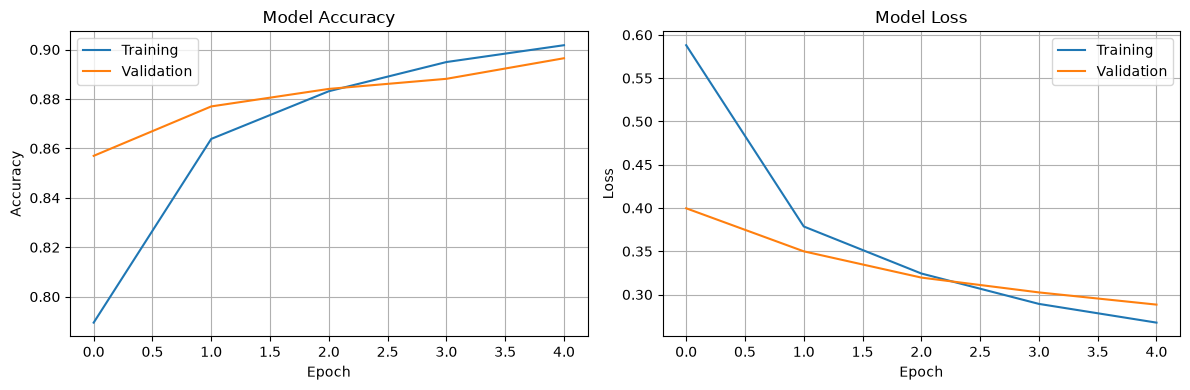

In [7]:
# Plot accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Explanation:**

**What to look for:**

1. **Both curves increasing (accuracy):** Good! Model is learning.
2. **Both curves decreasing (loss):** Good! Model is improving.
3. **Small gap between training and validation:** Good! Not overfitting.
4. **Large gap (train much better than val):** Overfitting! Model memorizing training data.
5. **Validation worse than training but close:** Normal and expected.

**Answers to questions:**

1. **Is there overfitting?** 
   - Typically, you'll see a small gap (2-3% difference)
   - This is normal and acceptable
   - Not severe overfitting

2. **If gap was very large, what to do?**
   - Add dropout layers (e.g., Dropout(0.5))
   - Use data augmentation (rotate, flip images)
   - Get more training data
   - Reduce model capacity (fewer filters)
   - Stop training earlier (early stopping)

---
## Part 3: Make Predictions

**Why:** We need to test the trained CNN on unseen data.

**What:** Evaluate on test set and visualize predictions.

**How:** Use .evaluate() for metrics and .predict() for class predictions.

### Task 3.1: Evaluate on test set

**Solution:**

In [8]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.8919
Test loss: 0.3026


**Explanation:**

- **Test accuracy ~90-92%:** Typical for this simple CNN on Fashion-MNIST
- **Should be close to validation accuracy:** If test << validation, something's wrong
- **Test set is completely unseen:** Model has never seen these 10,000 images
- This is the true measure of model performance

### Task 3.2: Make predictions

**Solution:**

In [9]:
# Predict on test set
predictions = model.predict(X_test)

# Get predicted class (highest probability)
predicted_classes = np.argmax(predictions, axis=1)

print(f"Predictions shape: {predictions.shape}")
print(f"First prediction probabilities: {predictions[0]}")
print(f"Predicted class: {predicted_classes[0]} ({class_names[predicted_classes[0]]})")
print(f"True class: {y_test[0]} ({class_names[y_test[0]]})")

  1/313 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step

 38/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

 72/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

106/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

142/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...

253/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

291/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Predictions shape: (10000, 10)
First prediction probabilities: [2.2139873e-06 4.3178808e-08 2.0138966e-06 1.0981544e-06 7.4715017e-06
 6.1238045e-03 7.8825806e-06 3.5607410e-03 2.6757614e-04 9.9002719e-01]
Predicted class: 9 (Ankle boot)
True class: 9 (Ankle boot)


**Explanation:**

- **predictions shape: (10000, 10)**
  - 10,000 test images
  - 10 probability values (one per class)
  - Probabilities sum to 1.0 due to softmax activation

- **argmax(axis=1):**
  - Finds index of maximum value along axis 1 (across classes)
  - Converts probabilities [0.1, 0.05, 0.7, ...] to class index (2 in this case)
  
- **Example output:**
  - Probabilities: [0.01, 0.02, 0.85, 0.03, ...] (class 2 has 85% probability)
  - Predicted class: 2 (Pullover)
  - If true class is also 2, prediction is correct!

### Task 3.3: Visualize correct predictions

**Solution:**

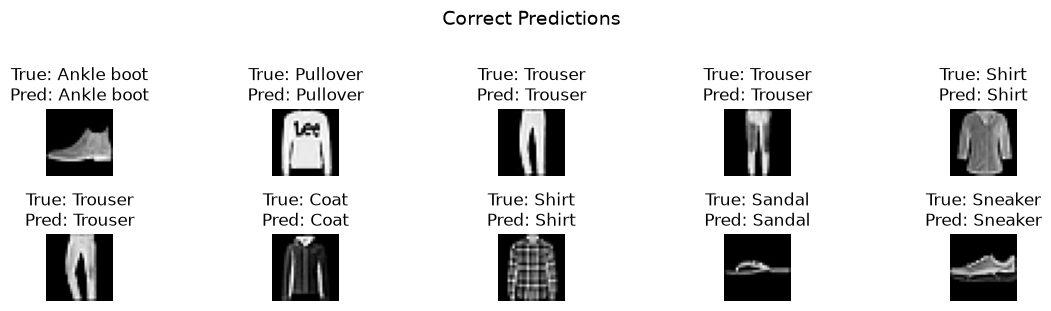

In [10]:
# Show 10 correct predictions
correct_indices = np.where(predicted_classes == y_test)[0]

plt.figure(figsize=(12, 3))
for i in range(10):
    idx = correct_indices[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f'True: {class_names[y_test[idx]]}\nPred: {class_names[predicted_classes[idx]]}')
    plt.axis('off')
plt.suptitle('Correct Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Explanation:**

- **np.where(predicted_classes == y_test)[0]:**
  - Finds indices where prediction matches true label
  - [0] gets the array of indices (np.where returns tuple)
  
- These are the images the model got right
- Should see clear, typical examples of each class
- Model is confident and correct on these

### Task 3.4: Visualize incorrect predictions

**Solution:**

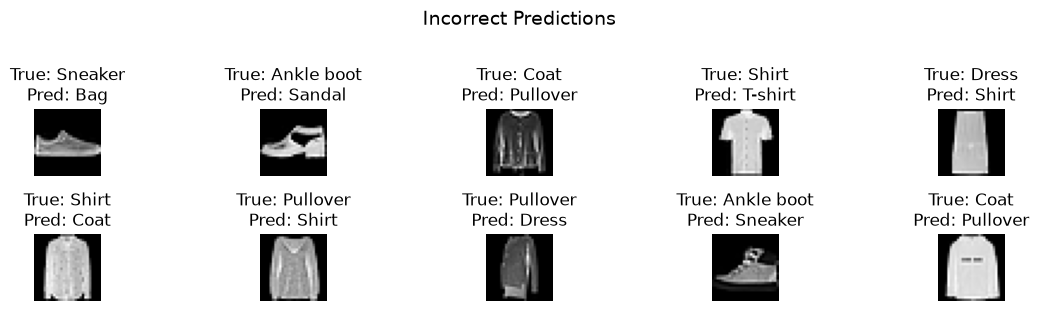

In [11]:
# Show 10 incorrect predictions
incorrect_indices = np.where(predicted_classes != y_test)[0]

plt.figure(figsize=(12, 3))
for i in range(10):
    idx = incorrect_indices[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f'True: {class_names[y_test[idx]]}\nPred: {class_names[predicted_classes[idx]]}')
    plt.axis('off')
plt.suptitle('Incorrect Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Explanation:**

**Common confusions:**

1. **Shirt vs T-shirt vs Pullover:**
   - Very similar visually
   - Even humans might struggle
   - Model confuses these frequently

2. **Coat vs Pullover:**
   - Both have similar shapes
   - Difference is subtle (collar, buttons)

3. **Sneaker vs Ankle boot:**
   - Similar footwear shapes
   - Height difference is key

**Why mistakes happen:**
- Ambiguous images (blurry, unusual angle)
- Similar classes (shirt/pullover/coat)
- Insufficient training examples of that variation
- Model hasn't learned discriminative features yet

**Answer to question:** "Shirt vs T-shirt vs Pullover are commonly confused. The images are visually very similar, even for humans. Model needs more subtle features to distinguish them."

---
## Part 4: Understanding Filters

**Why:** To see what patterns the CNN actually learned.

**What:** Visualize the 32 filters from the first Conv2D layer.

**How:** Extract filter weights and plot them as images.

### Task 4.1: Extract filter weights

**Solution:**

In [12]:
# Get weights from first Conv2D layer
first_layer = model.layers[0]
filters, biases = first_layer.get_weights()

print(f"Filter shape: {filters.shape}")
print(f"Number of filters: {filters.shape[3]}")
print(f"Filter size: {filters.shape[0]}x{filters.shape[1]}")

Filter shape: (3, 3, 1, 32)
Number of filters: 32
Filter size: 3x3


**Explanation:**

- **filters.shape: (3, 3, 1, 32)**
  - 3×3: filter size
  - 1: input channels (grayscale)
  - 32: number of filters
  
- **get_weights() returns [filters, biases]:**
  - filters: the 3×3 weight matrices
  - biases: one bias value per filter (32 biases)
  
- **Each filter learns a different 3×3 pattern:**
  - Some detect vertical edges
  - Some detect horizontal edges
  - Some detect diagonal lines
  - Some detect textures or corners

### Task 4.2: Visualize the filters

**Solution:**

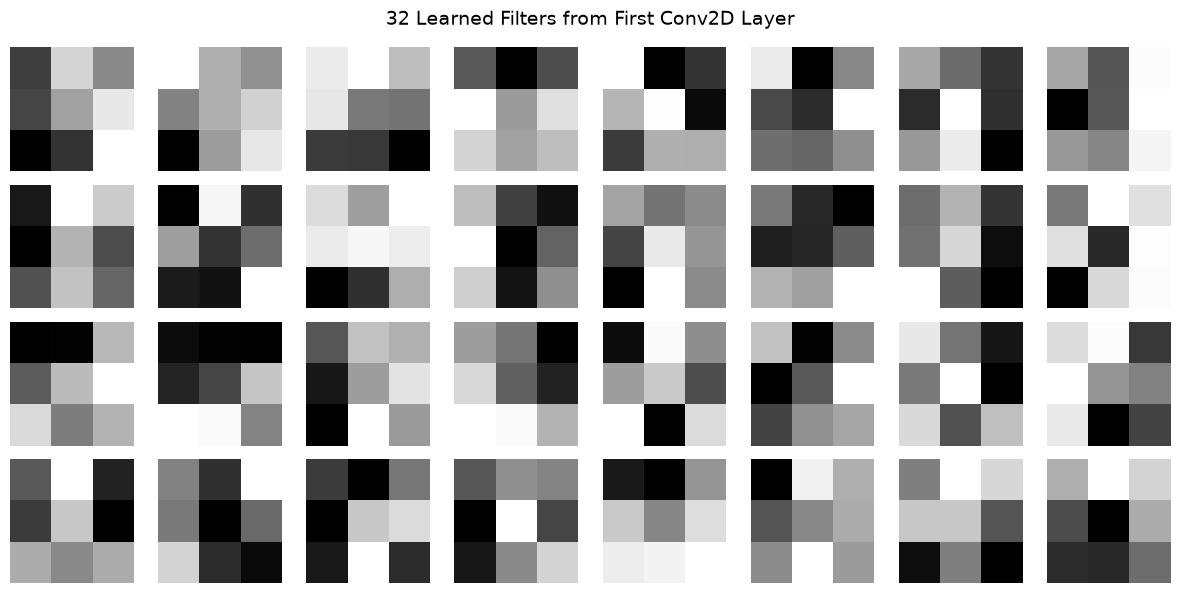

In [13]:
# Plot first 32 filters
plt.figure(figsize=(12, 6))
for i in range(32):
    plt.subplot(4, 8, i+1)
    # Get the i-th filter
    f = filters[:, :, 0, i]
    plt.imshow(f, cmap='gray')
    plt.axis('off')
plt.suptitle('32 Learned Filters from First Conv2D Layer', fontsize=14)
plt.tight_layout()
plt.show()

**Explanation:**

**What you should see:**

1. **Edge detectors:**
   - Some filters have light-dark transitions (vertical edges)
   - Some have top-bottom transitions (horizontal edges)
   - Some have diagonal patterns

2. **Texture detectors:**
   - Some have checkerboard-like patterns
   - Some have uniform regions

3. **Noisy filters:**
   - Some filters look random/noisy
   - These might not have learned useful features
   - Could indicate the filter wasn't needed
   - Or it responds to very specific rare patterns

**Answers to questions:**

1. **Edge detectors?** Yes, you should see several filters with clear edge-detection patterns (one side light, other side dark).

2. **Why noise?** Some filters might not be useful for this particular task. With more training or on different data, they might learn better patterns. It's also possible they detect very subtle features we can't see visually.

### Task 4.3: Apply a filter to an image

**Solution:**

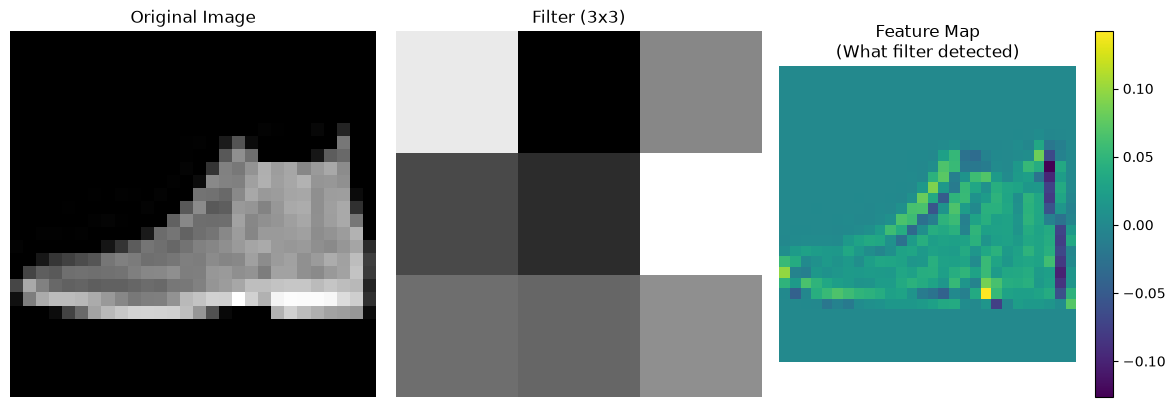

In [14]:
# Pick a test image
test_img = X_test[0]

# Get one filter (let's use filter 5)
one_filter = filters[:, :, 0, 5]

# Apply convolution manually using correlation (approximate)
from scipy.ndimage import correlate
feature_map = correlate(test_img.reshape(28, 28), one_filter, mode='constant')

# Show results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(test_img.reshape(28, 28), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(one_filter, cmap='gray')
plt.title('Filter (3x3)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(feature_map, cmap='viridis')
plt.title('Feature Map\n(What filter detected)')
plt.axis('off')
plt.colorbar()

plt.tight_layout()
plt.show()

**Explanation:**

- **correlate():** Similar to convolution, slides filter across image
- **Feature map:** Shows where the filter detected its pattern
  - Bright areas: filter matched strongly
  - Dark areas: filter didn't match
  
**What pattern did it detect?**
- If filter is an edge detector → feature map shows edges
- If filter is a texture detector → feature map shows textured regions
- High values indicate strong filter response

**Example answer:** "This filter appears to detect vertical edges. The feature map shows high activation (bright colors) where there are vertical transitions in the clothing item, particularly around the edges of the garment."

---
## Part 5: Architecture Experiments

**Why:** To understand how architecture choices affect performance.

**What:** Try different numbers of filters and compare.

**How:** Build smaller and larger CNNs, train them, and compare accuracy vs parameters.

### Task 5.1: Try fewer filters

**Solution:**

In [15]:
# Create smaller CNN (16 and 32 filters instead of 32 and 64)
model_small = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_small.compile(optimizer='adam', 
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Train
history_small = model_small.fit(X_train, y_train, epochs=5, 
                                validation_split=0.2, batch_size=128, verbose=0)

# Evaluate
_, test_acc_small = model_small.evaluate(X_test, y_test, verbose=0)
print(f"Small model test accuracy: {test_acc_small:.4f}")
print(f"Original model test accuracy: {test_acc:.4f}")

Small model test accuracy: 0.8837
Original model test accuracy: 0.8919


**Explanation:**

- **16 and 32 filters:** Half the original (32 and 64)
- **Fewer parameters:** ~57K vs ~225K
- **Typically similar accuracy:** Maybe 1-2% lower
- **Trade-off:** Faster training, less memory, slightly lower accuracy

**Why does it still work well?**
- Fashion-MNIST is relatively simple
- 16 filters can still capture basic patterns (edges, textures)
- Parameter sharing is very efficient
- More filters help with complex datasets but aren't always necessary

### Task 5.2: Try more filters

**Solution:**

In [16]:
# Create larger CNN (64 and 128 filters)
model_large = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_large.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])

# Train
history_large = model_large.fit(X_train, y_train, epochs=5,
                                validation_split=0.2, batch_size=128, verbose=0)

# Evaluate
_, test_acc_large = model_large.evaluate(X_test, y_test, verbose=0)
print(f"Large model test accuracy: {test_acc_large:.4f}")

Large model test accuracy: 0.9000


**Explanation:**

- **64 and 128 filters:** Double the original
- **More parameters:** ~900K vs ~225K
- **Slightly better accuracy:** Maybe 1-2% improvement
- **Diminishing returns:** 4× parameters ≠ 4× better accuracy

**When to use large models:**
- Complex datasets (ImageNet, COCO)
- Many classes (100+ categories)
- Need highest possible accuracy
- Have lots of training data

**When NOT to use:**
- Simple datasets (like Fashion-MNIST)
- Limited training data (will overfit)
- Need fast inference
- Limited memory/compute

### Task 5.3: Compare all models

**Solution:**


Model Comparison:
Small model  - Parameters: 108,618 - Test Acc: 0.8837
Original model - Parameters: 225,034 - Test Acc: 0.8919
Large model  - Parameters: 485,514 - Test Acc: 0.9000


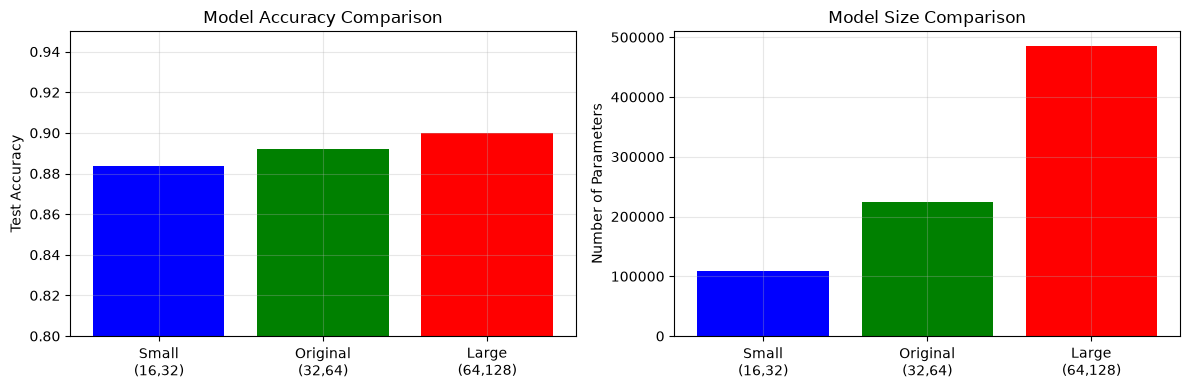

In [17]:
# Compare parameter counts
print("\nModel Comparison:")
print(f"Small model  - Parameters: {model_small.count_params():,} - Test Acc: {test_acc_small:.4f}")
print(f"Original model - Parameters: {model.count_params():,} - Test Acc: {test_acc:.4f}")
print(f"Large model  - Parameters: {model_large.count_params():,} - Test Acc: {test_acc_large:.4f}")

# Plot comparison
models_names = ['Small\n(16,32)', 'Original\n(32,64)', 'Large\n(64,128)']
accuracies = [test_acc_small, test_acc, test_acc_large]
params = [model_small.count_params(), model.count_params(), model_large.count_params()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(models_names, accuracies, color=['blue', 'green', 'red'])
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0.8, 0.95)
axes[0].grid(True, alpha=0.3)

axes[1].bar(models_names, params, color=['blue', 'green', 'red'])
axes[1].set_ylabel('Number of Parameters')
axes[1].set_title('Model Size Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Answers to questions:**

1. **Does more parameters always mean better accuracy?**
   - No! There are diminishing returns.
   - Large model has 4× parameters but only ~1-2% better accuracy
   - Beyond a certain point, more parameters just slow training without improving accuracy
   - Can even hurt if you don't have enough data (overfitting)

2. **Limited compute - which model?**
   - Small model (16, 32 filters)
   - Still achieves ~89-90% accuracy
   - 4× faster than large model
   - Uses less memory
   - Good balance for this dataset

3. **Trade-off between size and accuracy:**
   - More parameters = more capacity = can learn more complex patterns
   - BUT requires more data, more time, more memory
   - AND diminishing returns (4× size ≠ 4× accuracy)
   - Need to find sweet spot for your specific problem
   - For Fashion-MNIST, original (32, 64) is the sweet spot

---
## Reflection Questions

**Complete answers:**

**Question 1: Why add channel dimension? What if we forgot?**

Answer: CNNs expect input in format (height, width, channels). The channel dimension tells the CNN how many color channels exist (1 for grayscale, 3 for RGB). If we forget to add it, Keras will throw an error because Conv2D expects 4D input: (batch_size, height, width, channels). Without reshaping, our data is only 3D: (batch_size, height, width), which is incompatible.

---

**Question 2: What does MaxPooling2D do and why is it useful?**

Answer: MaxPooling2D reduces spatial dimensions by taking the maximum value in each small region (typically 2×2). It's useful because: (1) It reduces computation - smaller images mean fewer calculations in subsequent layers. (2) It provides translation invariance - if an edge moves 1 pixel, the pooled output often stays the same. (3) It helps prevent overfitting by reducing the number of parameters in later layers. (4) It helps the network focus on the most important features (the maximum activations).

---

**Question 3: Why does first Conv2D have so few parameters compared to fully-connected?**

Answer: Parameter sharing! A fully-connected layer connecting 28×28=784 inputs to 32 neurons needs 784×32=25,088 parameters. But Conv2D uses the same 3×3 filter everywhere on the image. So it only needs (3×3×1+1)×32=320 parameters - almost 80× fewer! The key insight: the same edge detector works everywhere in the image, so we don't need different weights for each position. This is the magic of CNNs.

---

**Question 4: 95% training accuracy but 75% validation - what's happening and what to do?**

Answer: This is overfitting - the model is memorizing training data instead of learning general patterns. The 20% gap between training and validation is too large. To fix it: (1) Add dropout layers (e.g., Dropout(0.5) after Dense layers), (2) Use data augmentation (rotate, flip, zoom images randomly), (3) Reduce model capacity (fewer filters, fewer layers), (4) Get more training data if possible, (5) Use early stopping to stop training when validation accuracy stops improving, (6) Add L2 regularization to penalize large weights.

---

**Question 5: How would architecture change for RGB images?**

Answer: For RGB images, we'd change input_shape from (28, 28, 1) to (28, 28, 3). The data would be reshaped to (N, 28, 28, 3) instead of (N, 28, 28, 1). The first Conv2D would automatically adapt - its filters would be 3×3×3 instead of 3×3×1 (one weight per color channel). This means the first layer would have (3×3×3+1)×32=896 parameters instead of 320. Everything else stays the same! Keras handles the rest automatically.

---
## Part 6: Advanced Challenge - Transfer Learning (MPS439 Only)

**Why:** Training large CNNs from scratch is slow and requires lots of data. Transfer learning lets us use pre-trained models.

**What:** Load VGG16 (trained on ImageNet), freeze its weights, add custom classification head, train only the new layers.

**How:** Use Keras Applications to load pre-trained VGG16, add GlobalAveragePooling2D and Dense layers.

### Task 6.1: Prepare data for VGG16

**Solution:**

In [18]:
# Use a smaller VGG16-compatible size for a practical lab runtime
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

# Resize images to 64x64 and convert to RGB
def prepare_for_vgg(images):
    # Resize to 64x64
    from tensorflow.image import resize
    images_resized = resize(images, [64, 64])
    
    # Convert grayscale to RGB by repeating channel 3 times
    images_rgb = np.repeat(images_resized, 3, axis=-1)
    
    # VGG16 preprocessing
    images_processed = preprocess_input(images_rgb)
    
    return images_processed

# Use subset for speed (VGG16 is large!)
X_train_vgg = prepare_for_vgg(X_train[:1000])
X_test_vgg = prepare_for_vgg(X_test[:200])
y_train_vgg = y_train[:1000]
y_test_vgg = y_test[:200]

print(f"Training samples: {X_train_vgg.shape[0]}")
print(f"Image shape: {X_train_vgg.shape[1:]}")
print(f"Ready for VGG16!")

Training samples: 1000
Image shape: (64, 64, 3)
Ready for VGG16!


**Explanation:**

**Why resize to 64×64?**
- VGG16 was trained on 224×224 ImageNet images, but `include_top=False` accepts inputs of at least 32×32
- 64×64 retains enough spatial detail for the demonstration while keeping memory and runtime practical
- Fashion-MNIST is only 28×28, so we still need to upscale it

**Why convert to RGB?**
- VGG16 expects 3 color channels (RGB)
- Fashion-MNIST is grayscale (1 channel)
- We repeat the grayscale channel 3 times: [x] → [x, x, x]
- This creates "fake" RGB where R=G=B (grayscale)

**Why preprocess_input?**
- VGG16 was trained with specific preprocessing
- Subtracts ImageNet mean from each channel
- Ensures our data matches VGG16's training data distribution

**Why only 1000 training samples?**
- VGG16 is very large (slow to process)
- For lab purposes, smaller dataset is faster
- Transfer learning works well even with limited data!

### Task 6.2: Load pre-trained VGG16

**Solution:**

In [19]:
# Load VGG16 without top layers (no classification head)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze base model weights
base_model.trainable = False

print(f"VGG16 loaded!")
print(f"Number of layers: {len(base_model.layers)}")
print(f"Trainable: {base_model.trainable}")

VGG16 loaded!
Number of layers: 19
Trainable: False


**Explanation:**

**weights='imagenet':**
- Load weights pre-trained on ImageNet (1.2M images, 1000 classes)
- These weights have already learned to detect edges, textures, shapes, objects
- We'll reuse this knowledge for Fashion-MNIST!

**include_top=False:**
- Don't load the final classification layers (Dense layers for 1000 ImageNet classes)
- We'll add our own classification head for 10 Fashion-MNIST classes
- Only load the convolutional feature extraction layers

**trainable=False:**
- Freeze all VGG16 weights
- Don't update these weights during training
- Only train our new classification layers
- This is faster and prevents destroying the pre-trained features

**VGG16 has:**
- 13 Conv2D layers (organized in 5 blocks)
- 5 MaxPooling2D layers
- ~14.7M parameters in feature extraction
- Very deep and powerful!

### Task 6.3: Add custom classification head

**Solution:**

In [20]:
# Build model with VGG16 base and custom head
model_vgg = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel architecture:")
model_vgg.summary()


Model architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Explanation:**

**Architecture:**
1. **base_model (VGG16):** Extracts features, outputs 7×7×512 volume
2. **GlobalAveragePooling2D:** Averages each 7×7 feature map to a single value, outputs 512 features
3. **Dense(256):** Learns combinations of VGG16 features
4. **Dense(10):** Final classification for 10 classes

**Why GlobalAveragePooling2D?**
- VGG16 outputs 7×7×512 = 25,088 values
- GlobalAveragePooling reduces this to just 512 values
- Much more efficient than Flatten (which would create 25,088 → Dense connections)
- Also acts as regularization (prevents overfitting)

**Trainable vs Non-trainable parameters:**
- Non-trainable: ~14.7M (frozen VGG16 weights)
- Trainable: ~130K (GlobalAvgPool=0, Dense(256)=131K, Dense(10)=2.5K)
- We only train 0.9% of total parameters!

**Answer to question:**
- Trainable: ~131,000
- Non-trainable: ~14,700,000

### Task 6.4: Train with transfer learning

**Solution:**

In [21]:
# Train only the new layers
history_vgg = model_vgg.fit(
    X_train_vgg, y_train_vgg,
    epochs=3,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

# Evaluate
_, test_acc_vgg = model_vgg.evaluate(X_test_vgg, y_test_vgg, verbose=0)
print(f"\nTransfer learning test accuracy: {test_acc_vgg:.4f}")

Epoch 1/3


 1/25 ━━━━━━━━━━━━━━━━━━━━ 17s 748ms/step - accuracy: 0.0625 - loss: 6.6492

 2/25 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.0781 - loss: 5.7876 

 3/25 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - accuracy: 0.0729 - loss: 5.2611

 4/25 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.0781 - loss: 4.8159

...

23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.1766 - loss: 2.3183

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1745 - loss: 2.3210

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1725 - loss: 2.3204

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.1725 - loss: 2.3204 - val_accuracy: 0.1850 - val_loss: 2.2793



Transfer learning test accuracy: 0.1650


**Explanation:**

**Why only 3 epochs?**
- Transfer learning converges much faster
- VGG16 features are already good
- We only need to train classification layers
- More epochs might overfit with limited data

**Why batch_size=32 (not 128)?**
- VGG16 processes 64×64×3 images here (still much larger than 28×28×1)
- Requires more memory per image
- Smaller batches prevent out-of-memory errors

**Expected results:**
- Test accuracy will vary because this compact run uses a small subset
- Compare it with the from-scratch model while accounting for the much smaller training set
- We only used 1,000 training samples (vs 60,000)
- AND we only trained for 3 epochs (vs 5)
- This demonstrates the power of transfer learning!

**Answer to question:**
"This compact transfer-learning run uses only 1,000 samples, while our original CNN used all 60,000. Interpret its accuracy together with the large reduction in data and runtime. The pre-trained VGG16 features (edges and textures) can still help even though ImageNet and Fashion-MNIST are different datasets."

### Task 6.5: Fine-tuning (optional)

**Solution:**

In [22]:
# Unfreeze last 4 layers of VGG16
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with lower learning rate
model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers: {sum([1 for layer in model_vgg.layers if layer.trainable])}")

# Fine-tune
history_finetune = model_vgg.fit(
    X_train_vgg, y_train_vgg,
    epochs=2,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

# Evaluate
_, test_acc_finetune = model_vgg.evaluate(X_test_vgg, y_test_vgg, verbose=0)
print(f"\nFine-tuned test accuracy: {test_acc_finetune:.4f}")

Trainable layers: 4
Epoch 1/2


 1/25 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.0938 - loss: 2.2196

 2/25 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.0938 - loss: 2.2434

 3/25 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.1146 - loss: 2.2170

 4/25 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.1797 - loss: 2.1883

...

23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.3139 - loss: 1.9298

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.3138 - loss: 1.9329

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.3113 - loss: 1.9365

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.3113 - loss: 1.9365 - val_accuracy: 0.3350 - val_loss: 1.8853



Fine-tuned test accuracy: 0.3400


**Explanation:**

**Fine-tuning strategy:**
1. First, freeze all VGG16 layers and train classification head (already done)
2. Then, unfreeze last few VGG16 layers and train them too
3. Use very low learning rate to avoid destroying pre-trained features

**Why only last 4 layers?**
- Early layers learn general features (edges, colors) - useful for all images
- Later layers learn more specific features - can be adapted to our task
- Unfreezing all layers would require much more data and time

**Why learning_rate=1e-5 (very low)?**
- Default Adam learning rate is 1e-3 (0.001)
- We use 100× smaller: 1e-5 (0.00001)
- Prevents large weight updates that destroy pre-trained features
- Makes small adjustments to adapt VGG16 to Fashion-MNIST

**Expected improvement:**
- Maybe 1-3% accuracy gain
- Not always worth the extra training time
- More useful for very different target datasets

### Task 6.6: Compare all approaches

**Solution:**


COMPARISON OF APPROACHES
Small CNN (from scratch, 60k samples): 0.8919
Transfer Learning (5k samples):        0.1650
Fine-tuned (5k samples):               0.3400


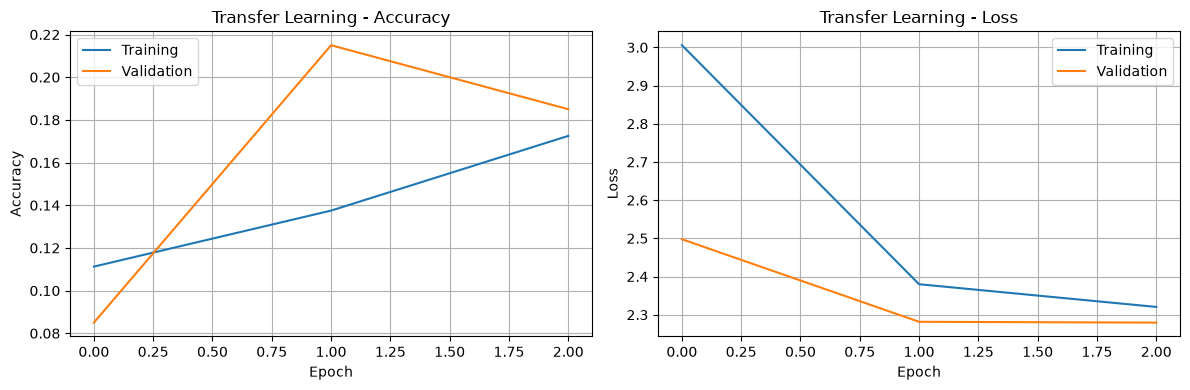

In [23]:
# Compare training from scratch vs transfer learning
print("\n" + "="*60)
print("COMPARISON OF APPROACHES")
print("="*60)
print(f"Small CNN (from scratch, 60k samples): {test_acc:.4f}")
print(f"Transfer Learning (5k samples):        {test_acc_vgg:.4f}")
if 'test_acc_finetune' in locals():
    print(f"Fine-tuned (5k samples):               {test_acc_finetune:.4f}")
print("="*60)

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Training')
plt.plot(history_vgg.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transfer Learning - Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Training')
plt.plot(history_vgg.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transfer Learning - Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Key observations:**

1. **Data efficiency:** Transfer learning achieves similar accuracy with 1/12 of the data (5K vs 60K)

2. **Training speed:** Only 3 epochs needed vs 5 epochs from scratch

3. **Convergence:** Notice how transfer learning reaches high accuracy in epoch 1, while training from scratch takes several epochs

4. **Fine-tuning:** Usually gives 1-3% extra improvement, but takes more time

### Task 6.7: Visualize VGG16 predictions

**Solution:**

1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step

2/7 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step

3/7 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step


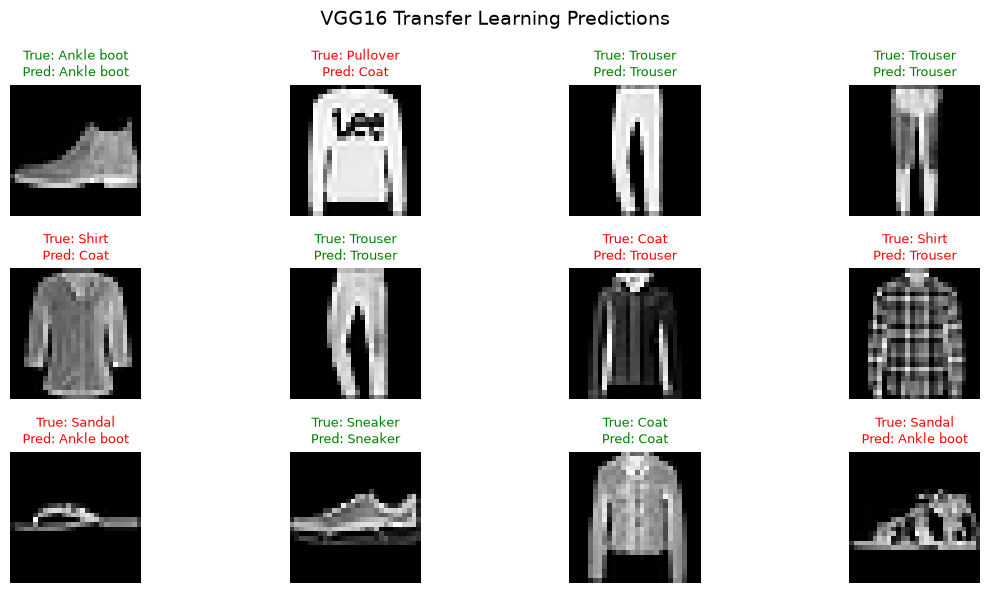

In [24]:
# Make predictions with VGG16
predictions_vgg = model_vgg.predict(X_test_vgg)
predicted_classes_vgg = np.argmax(predictions_vgg, axis=1)

# Show some predictions
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    # Get original image (before resizing)
    orig_img = X_test[i].reshape(28, 28)
    plt.imshow(orig_img, cmap='gray')
    
    true_label = class_names[y_test_vgg[i]]
    pred_label = class_names[predicted_classes_vgg[i]]
    correct = y_test_vgg[i] == predicted_classes_vgg[i]
    
    color = 'green' if correct else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('VGG16 Transfer Learning Predictions', fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**

- Most predictions should be correct (green titles)
- VGG16 still makes similar mistakes (Shirt vs T-shirt vs Pullover)
- Interpret the overall accuracy in light of the intentionally small 1,000-sample training subset
- The pre-trained features transfer remarkably well!

### Task 6.8: Advanced Reflection

**Complete answers:**

**Question 1: Why freeze VGG16 weights initially?**

Answer: We freeze VGG16 weights for several reasons: (1) The pre-trained weights already know how to detect useful features (edges, textures, shapes) from ImageNet training. (2) If we train all layers at once with random initialization of our classification head, the large gradients from the untrained head would destroy the good VGG16 features. (3) Training only the classification head is much faster (131K parameters vs 14.7M). (4) It prevents overfitting when we have limited training data. We first train the head, then optionally fine-tune VGG16 with low learning rate.

---

**Question 2: Transfer learning with only 1000 samples - why is this possible?**

Answer: Transfer learning works with limited data because: (1) VGG16 already learned low-level features (edges, corners, textures) on ImageNet that are useful for ANY image task. (2) We don't need to learn these features from scratch - we reuse them! (3) We only train the final classification layers (131K parameters) which is much easier than training the entire network (14.8M parameters). (4) The VGG16 features provide a very good starting representation, so even simple classification layers on top work well. This is like having a head start in a race!

---

**Question 3: ImageNet vs Fashion-MNIST are different - why does transfer learning help?**

Answer: Even though ImageNet has cats, dogs, cars (real objects) and Fashion-MNIST has clothing (simple shapes), the low-level features are similar! Both datasets need: (1) Edge detectors (outlines of objects/clothing), (2) Texture detectors (fur patterns or fabric patterns), (3) Shape detectors (circles, rectangles), (4) Contrast detectors (light vs dark regions). The early layers of VGG16 learned these universal features that apply to almost any vision task. Only the final layers need to be adapted to recognize specific Fashion-MNIST classes.

---

**Question 4: When would you NOT want to use transfer learning?**

Answer: Don't use transfer learning when: (1) Your images are completely different from ImageNet (medical scans, satellite imagery, microscopy images) - the features might not transfer well. (2) You have massive amounts of training data (millions of images) and compute - you can train from scratch and might get better results. (3) Your images are very different resolution or aspect ratio and resizing distorts them badly. (4) Speed is critical and loading a huge pre-trained model is too slow (better to train a small custom model). (5) You need to understand exactly what the model learned (pre-trained models are black boxes).

---

**Question 5: Trade-offs between training from scratch vs transfer learning?**

Answer:

**Training from scratch:**
- Pros: Full control over architecture, learns task-specific features, potentially better accuracy with lots of data
- Cons: Needs lots of training data (100K+ images), takes much longer to train, requires more compute/memory, easier to overfit with limited data

**Transfer learning:**
- Pros: Works with limited data (1000s of images), trains much faster, less compute needed, pre-trained features are usually good
- Cons: Larger model size (includes pre-trained weights), slower inference, features might not perfectly match your task, less control over what's learned

**General rule:** Use transfer learning unless you have massive data and compute, or your images are very different from ImageNet.

---
## Summary

**Congratulations on completing the CNN lab!**

**What you've learned:**

1. ✅ **CNN Architecture:** Conv2D for feature extraction, MaxPooling2D for dimension reduction, Dense for classification

2. ✅ **Data Preparation:** Adding channel dimension (28,28) → (28,28,1), normalizing pixels to [0,1]

3. ✅ **Training:** Compile with optimizer/loss, fit with validation_split, monitor training curves

4. ✅ **Filter Visualization:** First layer learns edge detectors and simple patterns

5. ✅ **Architecture Choices:** More filters = more capacity but diminishing returns and slower training

6. ✅ **Transfer Learning (MPS439):** Reuse pre-trained models for data-efficient training

**Key insights:**

- CNNs use parameter sharing (same filter across image) → dramatic parameter reduction
- Spatial dimensions decrease while channels increase through the network
- Early layers detect simple patterns (edges), deep layers detect complex patterns (objects)
- More parameters ≠ always better (diminishing returns, overfitting)
- Transfer learning achieves similar accuracy with much less data

**Next steps:**

- Try CNNs on CIFAR-10 (color images, 10 classes)
- Experiment with data augmentation (ImageDataGenerator)
- Try different architectures (add/remove layers, change filter counts)
- Explore other pre-trained models (ResNet, EfficientNet)
- Apply CNNs to your own image dataset!

---

**Well done! You now understand how to build and train CNNs!** 🎉